In [2]:
# Core
import os, re, string, math, warnings, sys, random
warnings.filterwarnings("ignore")

# Data & plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Saving model
import joblib

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Python:", sys.version.split()[0])
import sklearn, matplotlib
print("sklearn:", sklearn.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)


Python: 3.11.2
sklearn: 1.7.0
pandas: 2.3.1
matplotlib: 3.10.3


In [3]:
# >>>> CHANGE THESE if needed <<<<
FAKE_PATH = r"C:\Users\aadil\Downloads\Fake.csv"
TRUE_PATH = r"C:\Users\aadil\Downloads\True.csv"

# Load
fake = pd.read_csv(FAKE_PATH)
true = pd.read_csv(TRUE_PATH)

# Label: 0 = fake, 1 = real
fake["class"] = 0
true["class"] = 1

# Keep only columns we’ll use; tolerate missing columns
for df in (fake, true):
    for col in ("text", "title", "subject", "date"):
        if col not in df.columns:
            df[col] = np.nan

# Set aside a small manual test set (5+5) for the UI at the end
fake_mt = fake.sample(n=min(5, len(fake)), random_state=RANDOM_STATE)
true_mt = true.sample(n=min(5, len(true)), random_state=RANDOM_STATE)
manual_test = pd.concat([fake_mt, true_mt], ignore_index=True)

fake = fake.drop(index=fake_mt.index)
true = true.drop(index=true_mt.index)

# Merge
data = pd.concat([fake, true], ignore_index=True)

print(fake.shape, true.shape, data.shape)
data.head()


(23476, 5) (21412, 5) (44888, 5)


,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [4]:
# Keep only text + label
if "text" not in data.columns or "class" not in data.columns:
    raise ValueError("Input files must contain at least 'text' and 'class' columns.")

data = data[["text", "class"]].copy()

# Drop obvious empties, force to string
data["text"] = data["text"].fillna("").astype(str)

# Remove duplicates (optional)
before = len(data)
data = data.drop_duplicates(subset=["text", "class"]).reset_index(drop=True)
print(f"Dropped {before - len(data)} duplicate rows.")
print(data["class"].value_counts())


Dropped 6249 duplicate rows.
class
1    21187
0    17452
Name: count, dtype: int64


In [5]:
# Simple, robust cleaner
_punct_table = str.maketrans("", "", string.punctuation)

def clean_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"\[.*?\]", " ", s)                     # bracketed
    s = re.sub(r"https?://\S+|www\.\S+", " ", s)       # urls
    s = re.sub(r"<.*?>", " ", s)                       # html
    s = s.translate(_punct_table)                      # punctuation
    s = re.sub(r"\d+", " ", s)                         # numbers
    s = re.sub(r"\s+", " ", s).strip()                 # whitespace
    return s

data["text"] = data["text"].map(clean_text)

# Also clean manual set
manual_test["text"] = manual_test["text"].fillna("").astype(str).map(clean_text)

data.head()


,text,class
0,donald trump just couldn t wish all americans ...,0
1,house intelligence committee chairman devin nu...,0
2,on friday it was revealed that former milwauke...,0
3,on christmas day donald trump announced that h...,0
4,pope francis used his annual christmas day mes...,0


In [6]:
USE_LEMMATIZATION = False  # set True if you want it

if USE_LEMMATIZATION:
    try:
        import nltk
        from nltk.stem import WordNetLemmatizer
        nltk.download('wordnet', quiet=True)
        lemm = WordNetLemmatizer()

        def _lemmatize(doc: str) -> str:
            return " ".join(lemm.lemmatize(w) for w in doc.split())

        data["text"] = data["text"].map(_lemmatize)
        manual_test["text"] = manual_test["text"].map(_lemmatize)
        print("Applied lemmatization.")
    except Exception as e:
        print("Skipping lemmatization due to error:", e)


In [7]:
X = data["text"].values
y = data["class"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

len(X_train), len(X_test)


(28979, 9660)

In [8]:
X = data["text"].values
y = data["class"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

len(X_train), len(X_test)


(28979, 9660)

In [9]:
# One vectorizer used in all models (fits inside each Pipeline)
def make_vectorizer():
    return TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2,
        stop_words="english",  # avoids NLTK dependency
        sublinear_tf=True
    )

# Pipelines
pipe_lr = Pipeline([
    ("tfidf", make_vectorizer()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=None))
])

# LinearSVC needs calibration to get predict_proba
base_svc = Pipeline([
    ("tfidf", make_vectorizer()),
    ("clf", LinearSVC())
])
pipe_svc = Pipeline([
    ("cal", CalibratedClassifierCV(estimator=base_svc, cv=3, method="sigmoid"))
])

pipe_nb = Pipeline([
    ("tfidf", make_vectorizer()),
    ("clf", MultinomialNB(alpha=0.1))
])

models = {
    "LogisticRegression": pipe_lr,
    "LinearSVC_calibrated": pipe_svc,
    "MultinomialNB": pipe_nb
}
list(models.keys())


['LogisticRegression', 'LinearSVC_calibrated', 'MultinomialNB']


=== LogisticRegression ===
              precision    recall  f1-score   support

     Fake(0)       0.99      0.98      0.99      4363
     Real(1)       0.99      0.99      0.99      5297

    accuracy                           0.99      9660
   macro avg       0.99      0.99      0.99      9660
weighted avg       0.99      0.99      0.99      9660



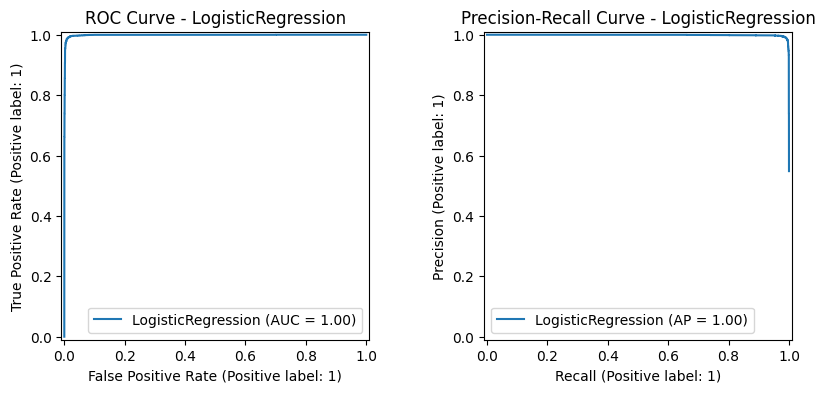


=== LinearSVC_calibrated ===
              precision    recall  f1-score   support

     Fake(0)       0.99      0.99      0.99      4363
     Real(1)       0.99      1.00      0.99      5297

    accuracy                           0.99      9660
   macro avg       0.99      0.99      0.99      9660
weighted avg       0.99      0.99      0.99      9660



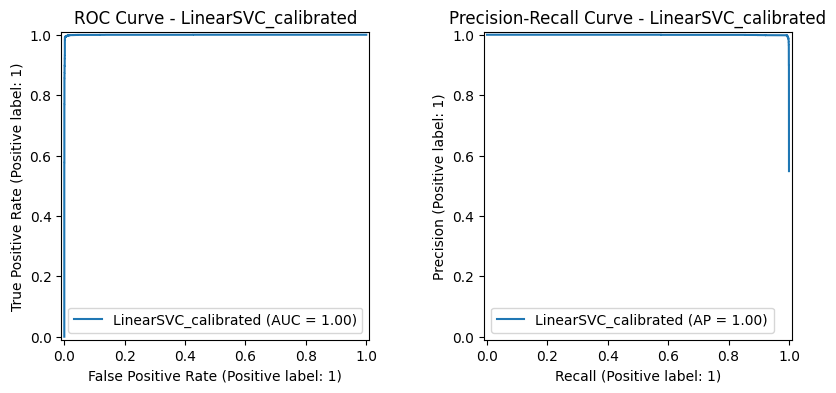


=== MultinomialNB ===
              precision    recall  f1-score   support

     Fake(0)       0.96      0.95      0.95      4363
     Real(1)       0.96      0.96      0.96      5297

    accuracy                           0.96      9660
   macro avg       0.96      0.95      0.95      9660
weighted avg       0.96      0.96      0.96      9660



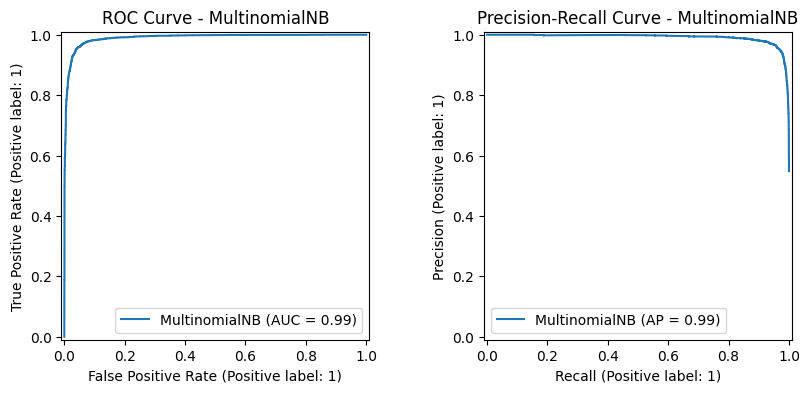

,model,accuracy,precision,recall,f1,roc_auc
0,LinearSVC_calibrated,0.993996,0.993222,0.995847,0.994532,0.999514
1,LogisticRegression,0.988302,0.985212,0.993581,0.989379,0.998843
2,MultinomialNB,0.955383,0.955447,0.963564,0.959489,0.989859


In [10]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

def evaluate_and_plot(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # Probability scores (needed for ROC/PR)
    try:
        y_score = model.predict_proba(X_te)[:, 1]
    except:
        try:
            y_score = model.decision_function(X_te)
        except:
            y_score = None

    # Metrics
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred),
        "recall": recall_score(y_te, y_pred),
        "f1": f1_score(y_te, y_pred)
    }
    if y_score is not None:
        metrics["roc_auc"] = roc_auc_score(y_te, y_score)
    else:
        metrics["roc_auc"] = np.nan

    print(f"\n=== {name} ===")
    print(classification_report(y_te, y_pred, target_names=["Fake(0)", "Real(1)"]))

    # Plots
    if y_score is not None:
        fig, axes = plt.subplots(1, 2, figsize=(10,4))
        RocCurveDisplay.from_predictions(y_te, y_score, ax=axes[0], name=name)
        PrecisionRecallDisplay.from_predictions(y_te, y_score, ax=axes[1], name=name)
        axes[0].set_title(f"ROC Curve - {name}")
        axes[1].set_title(f"Precision-Recall Curve - {name}")
        plt.show()

    return metrics

results = []
for name, model in models.items():
    m = evaluate_and_plot(name, model, X_train, y_train, X_test, y_test)
    results.append(m)

results_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
results_df


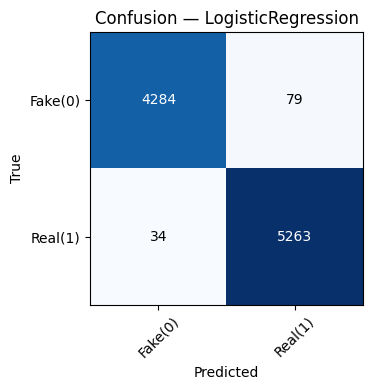

📊 Metrics for LogisticRegression:
   Accuracy : 0.9883
   Precision: 0.9852
   Recall   : 0.9936
   F1-score : 0.9894
----------------------------------------


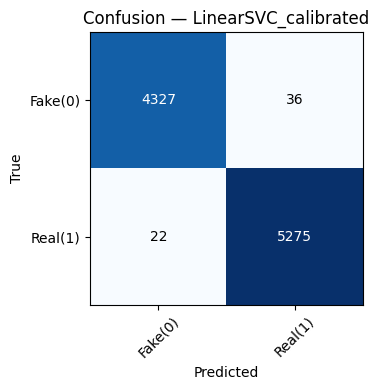

📊 Metrics for LinearSVC_calibrated:
   Accuracy : 0.9940
   Precision: 0.9932
   Recall   : 0.9958
   F1-score : 0.9945
----------------------------------------


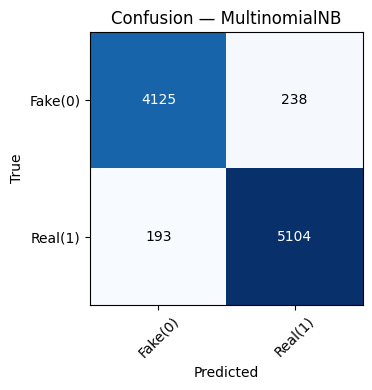

📊 Metrics for MultinomialNB:
   Accuracy : 0.9554
   Precision: 0.9554
   Recall   : 0.9636
   F1-score : 0.9595
----------------------------------------


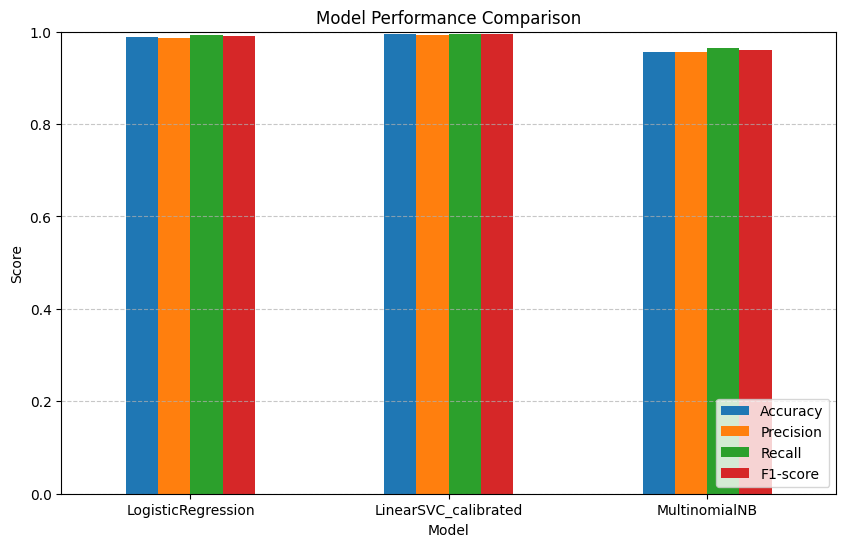

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(cm, classes, title="Confusion Matrix"):
    fig = plt.figure(figsize=(4.5, 4))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # write numbers inside the squares
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.show()


# ✅ Generate predictions, plot confusion matrix, and collect metrics
metrics_summary = {"Model": [], "Accuracy": [], "Precision": [], "Recall": [], "F1-score": []}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)                 # train model
    preds = model.predict(X_test)               # make predictions
    predictions[name] = preds                   # save in dict

    # Confusion matrix
    cm = confusion_matrix(y_test, preds)
    plot_confusion_matrix(cm,
                          classes=["Fake(0)", "Real(1)"],
                          title=f"Confusion — {name}")

    # Classification metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    # Save metrics for comparison
    metrics_summary["Model"].append(name)
    metrics_summary["Accuracy"].append(acc)
    metrics_summary["Precision"].append(prec)
    metrics_summary["Recall"].append(rec)
    metrics_summary["F1-score"].append(f1)

    print(f"📊 Metrics for {name}:")
    print(f"   Accuracy : {acc:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall   : {rec:.4f}")
    print(f"   F1-score : {f1:.4f}")
    print("-"*40)


# ✅ Convert metrics summary to DataFrame for easy plotting
import pandas as pd
metrics_df = pd.DataFrame(metrics_summary)

# Plot bar chart comparison
metrics_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar", figsize=(10,6), rot=0
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)  # scores between 0 and 1
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


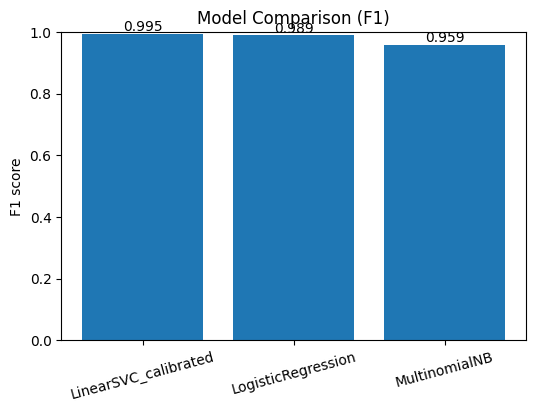

,model,accuracy,precision,recall,f1,roc_auc
0,LinearSVC_calibrated,0.993996,0.993222,0.995847,0.994532,0.999514
1,LogisticRegression,0.988302,0.985212,0.993581,0.989379,0.998843
2,MultinomialNB,0.955383,0.955447,0.963564,0.959489,0.989859


In [12]:
plt.figure(figsize=(6,4))
plt.bar(results_df["model"], results_df["f1"])
plt.title("Model Comparison (F1)")
plt.ylabel("F1 score")
plt.ylim(0, 1)
for i, v in enumerate(results_df["f1"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.xticks(rotation=15)
plt.show()

results_df


In [13]:
best_row = results_df.sort_values("f1", ascending=False).iloc[0]
best_name = best_row["model"]
best_model = models[best_name]
best_model.fit(X, y)  # retrain on ALL data for final model

SAVE_PATH = "best_fake_news_pipeline.joblib"
joblib.dump({"name": best_name, "pipeline": best_model}, SAVE_PATH)
print(f"Saved: {SAVE_PATH} | Best model: {best_name}")


Saved: best_fake_news_pipeline.joblib | Best model: LinearSVC_calibrated


In [14]:
# Helper that uses the in-memory best_model (already fitted)
def predict_text(text: str):
    text = "" if text is None else str(text)
    text = clean_text(text)
    if len(text.strip()) == 0:
        return {"label": None, "proba_real": None}
    proba = None
    try:
        p = best_model.predict_proba([text])[0][1]
        proba = float(p)  # probability of class 1 (real)
    except Exception:
        # Fall back: use decision and squash to 0..1
        try:
            d = best_model.decision_function([text])[0]
            proba = 1 / (1 + math.exp(-d))
        except Exception:
            proba = None
    label = int(best_model.predict([text])[0])
    return {"label": label, "proba_real": proba}

# Quick check
samples = [
    "Breaking! Government confirms new policy in press release.",
    "Shocking!!! Scientists hate him. See how he cured cancer at home!"
]
for s in samples:
    out = predict_text(s)
    print(s, "->", out)


Breaking! Government confirms new policy in press release. -> {'label': 0, 'proba_real': 0.0018227658753141914}
Shocking!!! Scientists hate him. See how he cured cancer at home! -> {'label': 0, 'proba_real': 0.001160669342375903}


In [15]:
import ipywidgets as w
from IPython.display import display, clear_output

# You can also switch to any trained model in `models` if you prefer
ui_model_choice = w.Dropdown(
    options=list(models.keys()),
    value=best_name,
    description="Model:"
)

ui_text = w.Textarea(
    value="Paste a news headline or short article here...",
    placeholder="Type or paste text",
    description="Input:",
    layout=w.Layout(width="100%", height="120px")
)

ui_btn = w.Button(description="Predict", button_style="primary")
ui_out = w.Output()

def on_model_change(change):
    global best_model, best_name
    best_name = change["new"]
    best_model = models[best_name]
    # Fit on ALL data to use immediately in UI
    best_model.fit(X, y)

ui_model_choice.observe(on_model_change, names="value")

def on_click(_):
    with ui_out:
        clear_output()
        res = predict_text(ui_text.value)
        if res["label"] is None:
            print("Please enter some text.")
            return
        
        label = "REAL (1)" if res["label"] == 1 else "FAKE (0)"
        print(f"Prediction: {label}")

        if res["proba_real"] is not None:
            p = res["proba_real"]

            # Matplotlib probability visualization
            plt.figure(figsize=(4,2))
            plt.barh(["Real", "Fake"], [p, 1-p], color=["green","red"])
            plt.xlim(0,1)
            plt.title("Prediction Probability")
            plt.show()
        else:
            print("Model does not provide probability; showing class only.")


ui = w.VBox([ui_model_choice, ui_text, ui_btn, ui_out])
ui_btn.on_click(on_click)
display(ui)

# Try examples from manual_test
print("\n--- Sample Manual Test Articles ---")
for i, row in manual_test.sample(frac=1, random_state=RANDOM_STATE).iterrows():
    short = row["text"][:140].replace("\n", " ")
    print(f"[{row['class']}] {short}...")



--- Sample Manual Test Articles ---
[1] new york reuters a federal judge rejected a request for a new trial by two former associates of new jersey governor chris christie who were ...
[0] the senate voted this afternoon to proceed to the resolution s con res which would set up a filibusterproof process ensuring the chamber s c...
[1] brussels reuters a leading european rights watchdog called on turkey on friday to ease postcoup state of emergency laws that have seen thous...
[0] ...
[1] hamburg reuters us president donald trump on saturday promised million in aid to feed people left starving because of drought and conflict i...
[0] so much for the scotus not being political check out her comments on equality for women it s like she s time traveled back to the s what is ...
[1] orangeburg sc reuters if democratic hopeful bernie sanders has a chance of drawing africanamerican voters away from rival hillary clinton in...
[0] donald trump may have decided that russia is going to be americ